## ddHodge workflow: for NTX injured muscle

>De Micheli AJ, Laurilliard EJ, Heinke CL, Ravichandran H, Fraczek P, Soueid-Baumgarten S, De Vlaminck I, Elemento O, Cosgrove BD. Single-Cell Analysis of the Muscle Stem Cell Hierarchy Identifies Heterotypic Communication Signals Involved in Skeletal Muscle Regeneration. Cell Rep. 2020 Mar 10;30(10):3583-3595.e5. doi: 10.1016/j.celrep.2020.02.067. PMID: 32160558; PMCID: PMC7091476.

https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE143437

## Setup

In [2]:
using GLMakie, JLD2, FreqTables, DataFrames, LinearAlgebra
using StatsBase: mean, median, cor, quantile

# To write the results back to h5ad (if required)
@isdefined(H5Adh) || include("../tools/H5ADHelper.jl")

# clipping for visualization
function clip(x,p=[0.01,0.99])
    position(p) = Int.(round.(length(x)*p))
    p = length(p)==1 ? [p,1-p] : p
    lower, upper = position.(p)
    xs = sort(x)
    clamp.(x,xs[lower],xs[upper])
end

clipmax(x;p=0.05) = maximum(abs.(clip(x,p)))

clipmax (generic function with 1 method)

In [3]:
forPrint = false # white background and SVG
if forPrint
    # for figure
    import CairoMakie
    CairoMakie.activate!(type="svg")
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
else
    # for daily use
    GLMakie.activate!(px_per_unit=1)
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
end
#Makie.theme(:fonts)

## Load data

select files and visualization methods (PCA/t-SNE/UMAP), then go

In [ ]:
h5file = "../data/scNTX.h5ad" # to be available in Figshare

import Muon
adata = Muon.readh5ad(h5file,backed=false)
viz = "umap"
names(adata.obs)

22-element Vector{String}:
 "sampleID"
 "nUMI"
 "nGene"
 "percent_mito"
 "injury"
 "cell_annotation"
 "n_genes_by_counts"
 "total_counts"
 "S_score"
 "G2M_score"
 "phase"
 "initial_size_unspliced"
 "initial_size_spliced"
 "initial_size"
 "n_counts"
 "velocity_self_transition"
 "leiden"
 "clusters"
 "ddh_u"
 "ddh_div"
 "ddh_rot"
 "ddh_vgrass"

In [5]:
npc = 40
X = adata.obsm["X_pca"][:,1:npc]'
V = adata.obsm["velocity_pca"][:,1:npc]'
loadings = adata.varm["PCs"][:,1:npc]
# for visualization
X_viz = adata.obsm["X_$viz"]'
V_viz = adata.obsm["velocity_$viz"]'
pts = Point2f.(eachcol(X_viz))
N = size(X,2)

34438

## Clusters

### Set main annotation and colors

lvs = ["FAPs", "Monocytes/Macrophages/Platelets", "Anti-inflammatory macrophages", "Endothelial", "MuSCs and progenitors", "Resident Macrophages/APCs", "Pro-inflammatory macrophages", "Mature skeletal muscle", "Smooth muscle cells", "B/T/NK cells", "Tenocytes", "Neural/Glial/Schwann cells"]


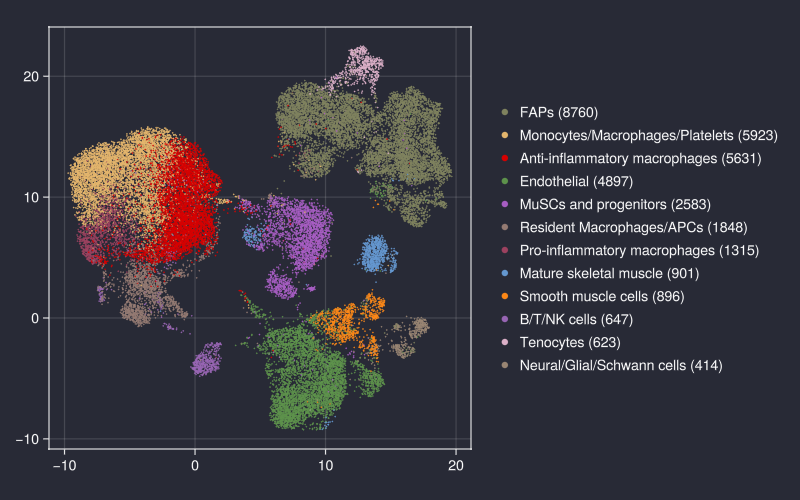

In [6]:
# Main annotation name to show
#anno = :clusters
anno = :cell_annotation
adata.obs.clusters = adata.obs.cell_annotation
#anno = :sampleID
#anno = :injury

ms = 2 # global marker size

cats = string.(adata.obs[!,anno])
lvs = levels(cats)
lvfreq = sort(freqtable(cats),rev=true)
cname = :glasbey_bw_minc_20_maxl_70_n256
#cname = :glasbey_hv_n256 #:glasbey_bw_minc_20_maxl_70_n256
#cname = :glasbey_bw_minc_20_minl_30_n256 # nice for darktheme
#cname = :tab10
cpal = Dict(zip(lvs,resample_cmap(cname,max(length(lvs),10))))
let
    lvs = names(lvfreq[1:min(15,length(levels(cats)))])[1] # show top 10 freq.
    lvs = lvs[lvfreq[lvs] .>= 2] # at least 2 cells
    #lvs = sort(lvs)
    @show lvs
    labels = [string(lv)*" ($(lvfreq[lv]))" for lv in lvs]
    fig = Figure(size=(800,500))
    ax = Axis(fig[1,1],aspect=1)
    scatter!(ax, pts, markersize=ms, color=[cpal[c] for c in cats],rasterize=2)
    Legend(fig[1,2],[MarkerElement(marker=:circle, color=cpal[p]) for p in lvs],labels,nbanks=1)
    fig
end

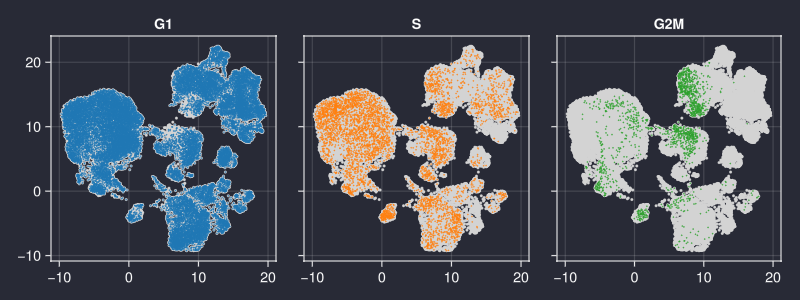

In [7]:
let ms = ms
    cats = adata.obs.phase
    lvs = ["G1","S","G2M"]
    ppal = Dict(zip(lvs,resample_cmap(:tab10,10)))
    pcols = [get(ppal,c,:lightgrey) for c in cats]
    fig = Figure(size=(800,300),)
    axs = [Axis(fig[1,i],aspect=1,title=lvs[i]) for i in 1:length(lvs)]
    for i in 1:3
        scatter!(axs[i],pts,markersize=4,color=:lightgrey)
        pshow = cats .== lvs[i]
        scatter!(axs[i],pts[pshow],markersize=ms,color=(ppal[lvs[i]],0.9))
    end
    [axs[i].yticklabelsvisible = false for i in 2:3]
    linkaxes!(axs...)
    fig
end

## Workflow

In [8]:
struct Params
    k::Int
    d::Int
    λ::AbstractFloat
    ϵ::AbstractFloat
end

#par = Params(12,4,0.1,1.0)
par = Params(12,4,0.1,1.0)
#par = Params(30,8,0.1,1.0)

Params(12, 4, 0.1, 1.0)

### Graph construction

In [35]:
using ddHodge
@time g, kdtree = kNNGraph(X,par.k) # slow for higher dimension

  3.000602 seconds (1.08 M allocations: 55.480 MiB)


(Graphs.SimpleGraphs.SimpleGraph{Int64}(308606, [[135, 503, 965, 1064, 1671, 1896, 2016, 3455, 4896, 4909, 27231, 27458, 27950, 28231, 28313, 29295, 29770, 30728], [1121, 1449, 1660, 1852, 1853, 2207, 2634, 2661, 3423, 3857, 4198, 5165, 30651], [258, 305, 412, 592, 605, 840, 888, 986, 1238, 1255  …  2947, 3607, 3641, 3660, 4184, 4267, 4355, 4542, 4594, 29227], [189, 248, 376, 436, 697, 847, 995, 1186, 1223, 1314, 1502, 1531, 2456, 2965], [108, 157, 583, 907, 1142, 1253, 1257, 1539, 1634, 1977, 4804, 5345, 5478, 27741], [217, 1544, 2111, 2381, 3121, 3287, 4077, 4135, 26915, 27397, 28095, 29534, 30214], [98, 635, 856, 941, 1293, 1321, 2571, 3940, 4627, 5097, 5203, 5392, 27628, 27762, 27901, 30537, 30793, 30806, 30859, 34300], [24, 188, 1219, 1898, 2741, 3314, 4448, 4537, 5235, 5355, 5371, 30724], [2696, 3172, 3216, 3999, 4593, 5214, 5424, 5494, 5537, 28131, 29024, 29074, 30652], [20, 122, 222, 282, 789, 835, 977, 1013, 1788, 2420, 2433, 2766, 2990, 3205, 4087, 4431]  …  [1666, 7820, 1572

In [36]:
import CUDA
resume = false
jldfile = join(["../data/",split(basename(h5file),'.')[1],"_pca_k$(par.k)_d$(par.d).jld2"])
@show jldfile
ddh = if resume & isfile(jldfile)
    @time load(jldfile)["ddh"]
else
    CUDA.@time ddh = ddHodgeWorkflow(g,X,V,rdim=par.d,λ=par.λ,ϵ=par.ϵ,ssa=true,ssart=2,krytol=1e-32,useCUDA=true);
    #ddh = ddHodgeWorkflow(g,X,V,rdim=par.d,λ=par.λ,ϵ=par.ϵ,ssa=true,ssart=1,krytol=1e-32,useCUDA=false);
    save(jldfile,"ddh",ddh)
    ddh
end

jldfile = "../data/scNTX_pca_k12_d4.jld2"


[ Info: (1/4) Potential estimation
[ Info: ... done in 3.177 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 0.5623805110723706
[ Info: ... done in 9.154 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 4.806 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 0.5572347912872725
[ Info: ... done in 6.307 sec.


 23.597053 seconds (72.71 M CPU allocations: 15.823 GiB, 18.15% gc time) (84.72 k GPU allocations: 6.089 GiB, 1.09% memmgmt time)


:::ddHodge::: values over graph {34438, 308606}, dimensions: 40 -> 4 (ssa: on)

## Check results

n2s[2:3] / n2s[1] = [0.788683179913486, 0.2113168200865124]


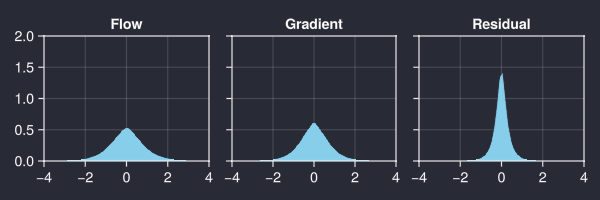

In [11]:
let
    fig = Figure(size=(600,200))
    titles = ["Flow", "Gradient", "Residual"]
    values = [ddh.w, -ddh.d0*ddh.u, ddh.w+ddh.d0*ddh.u]/sqrt(mean(abs2.(ddh.w)))
    n2s = norm.(values).^2
    @show (n2s[2:3]/n2s[1])
    axs = [Axis(fig[1,i],title=titles[i]) for i in 1:3]
    #[hist!(axs[i], values[i], bins=200, color=:skyblue,normalization=:pdf,rasterize=2) for i in 1:3]
    [density!(axs[i], values[i], rasterize=2, color=:skyblue) for i in 1:3]
    [axs[i].yticklabelsvisible = false for i in 2:3]
    xlims!.(axs,-4,4)
    ylims!.(axs,0,2)
    linkaxes!(axs...)
    fig
end

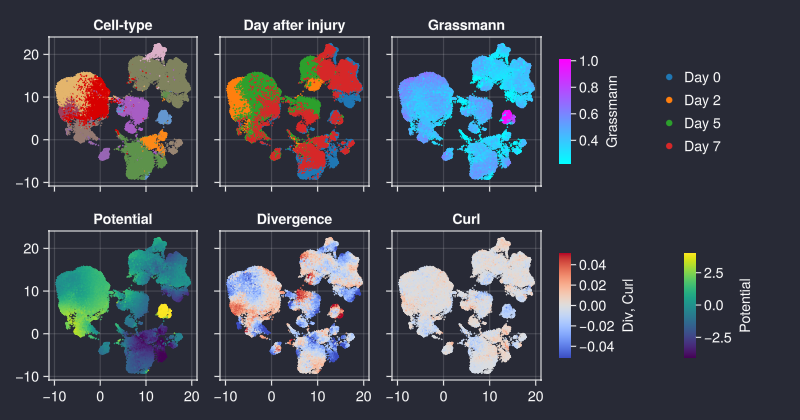

In [12]:
fig = let ms = ms, clp = 0.01
    speeds = norm.(eachcol(V))
    dlev = levels(adata.obs.injury)
    dpal = Dict(zip(dlev,resample_cmap(:tab10,10)))
    fig = Figure(size=(800,420))
    titles = ["Cell-type", "Day after injury", "Grassmann", "Potential", "Divergence", "Curl"]
    axs = [Axis(fig[divrem(i-1,3).+1...],title=titles[i],aspect=1) for i in 1:length(titles)]
    scatter!(axs[1], pts, markersize=ms, color=[cpal[c] for c in cats],rasterize=2)
    scatter!(axs[2], pts, markersize=ms, color=[dpal[d] for d in adata.obs.injury],rasterize=2)
    #stream!(axs[1],gridsize=(40,40),arrow_size=8)
    pltg = scatter!(axs[3],pts,color=clip(ddh.vgrass,clp),markersize=ms,colormap=:cool,rasterize=2)
    #plts = scatter!(axs[4],pts, color=clip(speeds,clp), colormap=:plasma,markersize=ms,rasterize=2)
    pltu = scatter!(axs[4], pts, color=clip(ddh.u,clp), colormap=:viridis, markersize=ms,rasterize=2)
    vmax = clipmax([ddh.div;ddh.rot],p=clp)
    pltd = scatter!(axs[5], pts, color=ddh.div, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax),rasterize=2)
    scatter!(axs[6], pts, color=ddh.rot, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax),rasterize=2)
    Colorbar(fig[1,4],pltg,label="Grassmann",height=Relative(0.7))
    Colorbar(fig[2,5],pltu,height=Relative(0.7),label="Potential")
    Colorbar(fig[2,4],pltd,height=Relative(0.7),label="Div, Curl")
    #Colorbar(fig[2,5],plts,height=Relative(0.7),label="Speed",vertical=true)
    Legend(fig[1,5],[MarkerElement(marker=:circle, color=dpal[d]) for d in dlev],dlev)
    [axs[i].xticklabelsvisible = false for i in 1:3]
    [axs[i].yticklabelsvisible = false for i in [2,3,5,6]]
    linkaxes!(axs...)
    fig
end

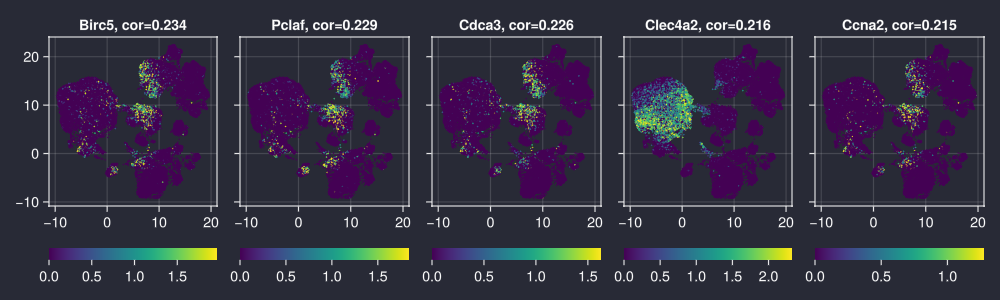

In [13]:
let vals=ddh.div, thr=0.01, ms=ms, cmap=:viridis
    cc = vec(cor(adata.X,vals))
    idx = sortperm(abs.(cc);rev=true)[1:5]
    genes = adata.var_names[idx]
    corrs = round.(cc[idx],digits=3)
    n = length(genes)
    idxs = indexin(genes,adata.var_names)
    fig = Figure(size=(1000,300))
    axs = [Axis(fig[1,i],title="$(genes[i]), cor=$(corrs[i])",aspect=1) for i in 1:n]
    for i in 1:n
        expr = collect(adata.X[:,idxs[i]])
        plt=scatter!(axs[i],pts,color=clip(expr,thr),markersize=ms,colormap=cmap,rasterize=2)
        Colorbar(fig[2,i],plt,vertical=false,flipaxis=false)
    end
    [axs[i].yticklabelsvisible=false for i in 2:n]
    linkaxes!(axs...)
    fig
end

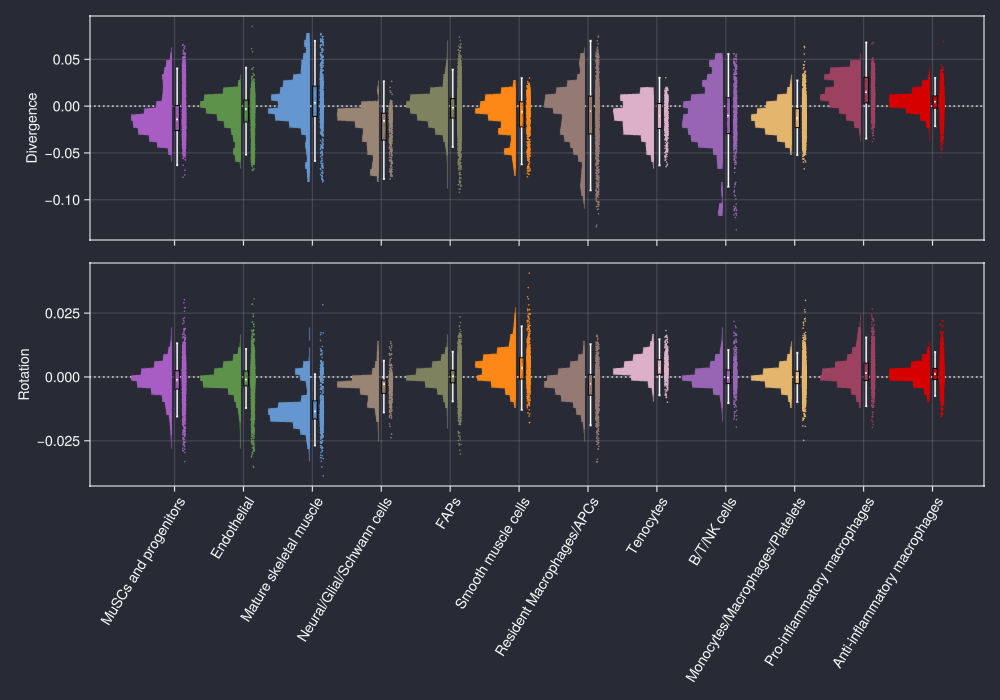

In [14]:
let
    fig = Figure(size=(1000,700))
    ax1 = Axis(fig[1,1],xticklabelrotation=45.0,ylabel="Divergence")
    ax2 = Axis(fig[2,1],xticklabelrotation=45.0,ylabel="Rotation")
    hlines!(ax1, [0], color=:lightgrey, linestyle=:dot)
    rainclouds!(ax1, string.(cats), ddh.div, color=[cpal[c] for c in cats],clouds=hist,rasterize=2)
    hlines!(ax2, [0], color=:lightgrey, linestyle=:dot)
    rainclouds!(ax2, string.(cats), ddh.rot, color=[cpal[c] for c in cats],clouds=hist,rasterize=2)
    ax1.xticklabelsvisible=false
    ax1.xticks=1:length(unique(cats))
    ax2.xticks=(1:length(unique(cats)),unique(string.(cats)))
    linkxaxes!(ax1,ax2)
    fig
end

## Write back to h5ad

In [15]:
### Reflect the results to loaded anndata
let 
    featurestowrite = [:u,:div,:rot,:vgrass]
    [adata.obs[!,"ddh_$(ft)"] = getfield(ddh,ft) for ft in featurestowrite]
    H5Adh.insertddh(h5file,ddh,keys=featurestowrite) # save if needed
end

## Cycles

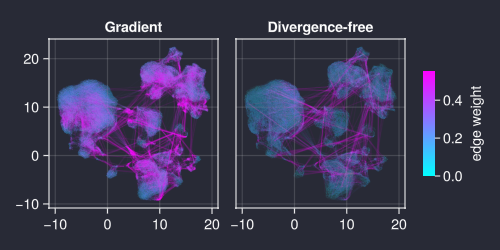

In [16]:
using GraphMakie
let cmap = :cool
    titles = ["Gradient","Divergence-free"]
    gr = [-ddh.d0*ddh.u ddh.w+ddh.d0*ddh.u]
    wmax = quantile(vec(gr),0.99)
    fig = Figure(size=(500,250))
    axs = [Axis(fig[1,i],aspect=1,title=titles[i]) for i in axes(gr,2)]
    for i in axes(gr,2)
        w = gr[:,i]
        graphplot!(
            axs[i], g, layout=pts, node_size=0,
            edge_color=abs.(w), edge_width=0.05abs.(w),
            edge_attr=(;colormap=cmap,colorrange=(0,wmax)),
            transparency=true, rasterize=2,
        )
    end
    Colorbar(
        fig[1,3],colormap=cmap,colorrange=(0,wmax),
        height=Relative(0.6),label="edge weight"
    )
    hideydecorations!.(axs[2], grid = false)
    linkaxes!(axs...)
    fig
end

## Point of interest

### Select cells of extrema in diverngence from each clusters

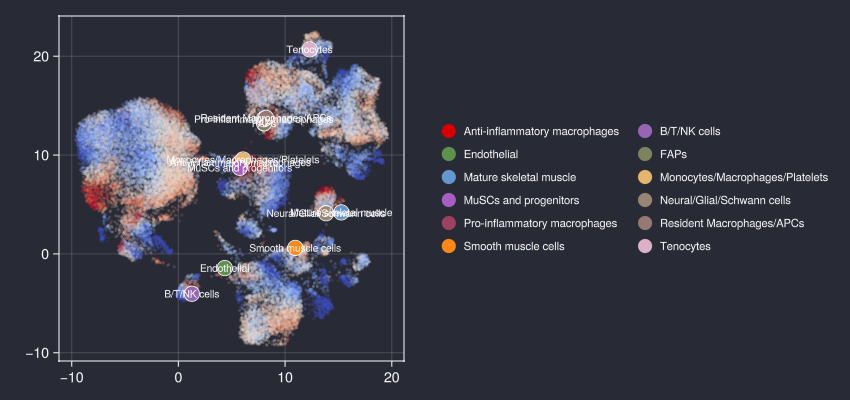

In [17]:
targetval = :div
elite = combine(
    sdf -> sdf[argmax(sdf[!,"ddh_$targetval"]),:], # max. targetval
    #sdf -> sdf[argmin(sdf[!,"ddh_$targetval"]),:], # min. targetval
    groupby([DataFrame(number=axes(adata.obs,1)) adata.obs],:clusters)
)

let thr=0.05, ms=20, shape=:circle, numcol=:white
    lvs = unique(string.(elite[!,anno]))
    vals = getfield(ddh,targetval)
    vmax = clipmax(vals,p=thr)
    fig = Figure(size=(850,400))
    ax = Axis(fig[1,1],aspect=1)
    scatter!(ax,pts,color=vals,alpha=0.2,markersize=4,colormap=:coolwarm,colorrange=(-vmax,vmax),rasterize=2)
    scatter!(ax,pts[elite.number],color=[cpal[c] for c in elite[!,anno]],marker=shape,markersize=20,strokewidth=1,strokecolor=:white)
    text!(ax,pts[elite.number],text=string.(elite.clusters),align=(:center,:center),fontsize=10,color=numcol)
    Legend(fig[1,2],[MarkerElement(marker=shape,markersize=ms, color=cpal[p]) for p in lvs],lvs,nbanks=2,labelsize=11)
    fig
end

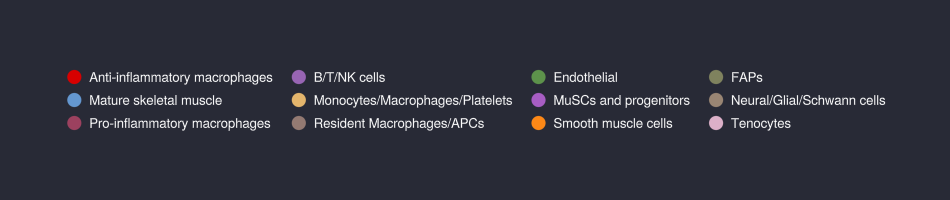

In [18]:
let
    fig = Figure(size=(950,200))
    lvs = string.(elite[!,anno])
    Legend(fig[1,1],[MarkerElement(marker=:circle, markersize=20, color=cpal[elite[i,anno]]) for i in axes(elite,1)],lvs,nbanks=4,labelsize=13)
    #save("test.pdf",fig)
    fig
end

In [19]:
sort(elite,"ddh_$targetval")[!,unique([:clusters,:ddh_div,:ddh_rot,anno])]

Row,clusters,ddh_div,ddh_rot,cell_annotation
,String,Float64,Float64,String
1,Neural/Glial/Schwann cells,0.0265769,-0.0103961,Neural/Glial/Schwann cells
2,Smooth muscle cells,0.0299804,0.000217226,Smooth muscle cells
3,Tenocytes,0.0303254,0.00187726,Tenocytes
4,B/T/NK cells,0.0558227,1.61418e-5,B/T/NK cells
5,Monocytes/Macrophages/Platelets,0.0638717,0.0145691,Monocytes/Macrophages/Platelets
6,MuSCs and progenitors,0.0655498,0.00719688,MuSCs and progenitors
7,Pro-inflammatory macrophages,0.0680825,-0.00102333,Pro-inflammatory macrophages
8,Anti-inflammatory macrophages,0.0690335,0.000117452,Anti-inflammatory macrophages
9,FAPs,0.0737972,0.00282958,FAPs


### Select the dimensions of interest
Basis of J should be transformed to the original dimension before applying schur

In [20]:
targetcluster = "MuSCs and progenitors"
targetcell = elite.number[findfirst(elite.clusters.==targetcluster)]
sf = let i = targetcell
    schur(basischange(ddh.J[i],ddh.frames[i],ddh.spans[i]))
end
svdf = sort(DataFrame(index=1:ddh.rdim,value=sf.values),order(:value,by=real,rev=true))

Row,index,value
,Int64,Float64
1,1,0.0369219
2,2,0.0253735
3,3,0.00483011
4,4,-0.0015757


In [21]:
let i = targetcell
    @show 0.5ddh.rot[i]
    @show imag.(eigvals(ddh.J[i]+ddh.H[i]))
    @show ddh.div[i], -tr(ddh.H[i])
    eigvals(basischange(ddh.J[i]+ddh.H[i],ddh.frames[i],ddh.planes[i]))
end

0.5 * ddh.rot[i] = 0.003598441156506955
imag.(eigvals(ddh.J[i] + ddh.H[i])) = [0.0, -0.0031255294599738664, 0.0031255294599738664, 0.0]
(ddh.div[i], -(tr(ddh.H[i]))) = (0.06554979716116621, 0.06554979716116621)


2-element Vector{ComplexF64}:
 6.505213034913027e-19 - 0.003125529459973867im
 6.505213034913027e-19 + 0.003125529459973867im

### Project the target and the neighbors onto the invariant subspace

In [22]:
# target dimension to analyse (select by the eigvals above)
tdims = sort(svdf[isreal.(svdf.value),:index][1:2]) # shoud be sorted
#tdims = sort(svdf[isreal.(svdf.value),:index][end-1:end]) # shoud be sorted
@show tdims
#tdims = sort([1,2])
#tdims = sort([3,4])
S, neis, xoi, voi = let i = targetcell, nnei = 2000, addvel = false
    svals, svecs = schurselect(sf,tdims)
    @show svals
    S = ddh.spans[i]*svecs # selected subspace
    # add velocity direction to last one
    addvel && (S = [ddh.spans[i]*ddh.spans[i]'V[:,i] S])
    if nnei > 0 # flag for select same cluster
        neis, = ddHodge.knn(kdtree,X[:,i],nnei,true)
    else
        neis = findall(adata.obs.clusters .== adata.obs.clusters[i])
        neis = neis[sortperm(norm.(eachcol(X[:,neis].-X[:,i])))]
    end
    xoi = S'*(X[:,neis].-X[:,i]) |> eachcol .|> Point2f
    voi = S'*V[:,neis] |> eachcol .|> Point2f
    (S, neis, xoi, voi)
end
length(neis)

tdims = [1, 2]
svals = [0.036921865287209185, 0.0253735243097479]


2000

### Which part was selected in UMAP

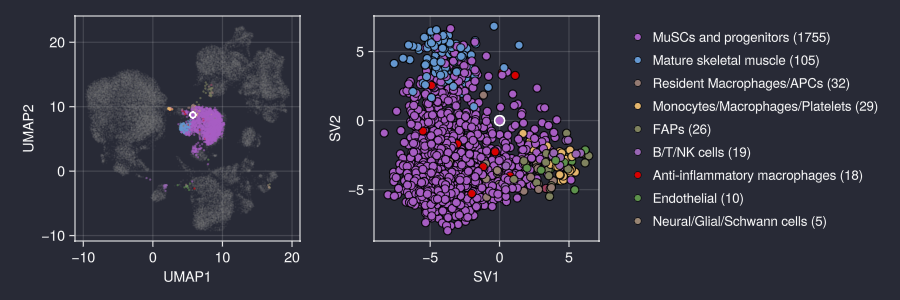

In [23]:
melm(c) = MarkerElement(marker=:circle, strokewidth=0.5, color=c)
fig = let i = targetcell
    cluster = lpad(adata.obs.clusters[i],2,'0')
    lvfreq = sort(freqtable(cats[neis]),rev=true)
    lvs = names(lvfreq[1:min(10,length(lvfreq))])[1] # show top 10 freq.
    lvs = lvs[lvfreq[lvs] .>= 2] # at least 2 cells
    labels = [string(lv)*" ($(lvfreq[lv]))" for lv in lvs]
    fig = Figure(size=(900,300))
    ax1 = Axis(fig[1,1],aspect=1,xlabel="UMAP1",ylabel="UMAP2")
    ax2 = Axis(fig[1,2],aspect=1,xlabel="SV$(tdims[1])",ylabel="SV$(tdims[2])")
    scatter!(ax1, pts, markersize=2, color=(:grey,0.1),rasterize=2)
    scatter!(ax1,pts[neis],markersize=3,color=[(cpal[c],0.6) for c in cats[neis]],rasterize=2)
    scatter!(ax1,pts[i],markersize=5,color=cpal[cats[i]],strokewidth=2,strokecolor=:white)
    scatter!(ax2,xoi,markersize=10,color=[cpal[c] for c in cats[neis]],strokewidth=1,rasterize=2)
    scatter!(ax2,xoi[1],markersize=11,color=cpal[cats[i]],strokewidth=2,strokecolor=:white)
    Legend(fig[1,3],[melm(cpal[p]) for p in lvs],labels,nbanks=1,labelsize=13)
    fig
end

## Top correlated genes expression in selected cells

Row,gene,H2az1,Birc5,Pclaf,Stmn1,Hmgb2,Cdca3,Cenpa,Ccna2,Cdca8,Cks1b,Selenoh,Ptma,Spc24,Hmgb1,Ranbp1,Ccnb2,D17H6S56E-5,Tk1,Cdc20,Cdk1
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,cor_div,0.695115,0.656501,0.618036,0.61562,0.614021,0.605656,0.598283,0.588759,0.563317,0.559104,0.552893,0.547548,0.545044,0.54473,0.539073,0.538947,0.531143,0.524881,0.52327,0.522025
2,cor_rot,-0.237549,-0.235579,-0.17305,-0.230136,-0.203264,-0.227391,-0.22362,-0.188762,-0.201419,-0.17864,-0.179697,-0.254639,-0.220979,-0.14763,-0.0974181,-0.227231,-0.192142,-0.145205,-0.213464,-0.162761


Row,gene,Zbtb20,Rora,Lama2,Arhgap24,Htra3,Pde4d,Ypel3,Gpx3,Dag1,Dlg2,Cdkn1c,Ptprd,Spats2l,Eef2,Serping1,Auts2,Palld,Rtn2,Tln2,Islr,Arhgap42
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,cor_div,-0.496165,-0.490782,-0.424007,-0.407679,-0.400688,-0.400173,-0.380467,-0.345865,-0.334803,-0.333588,-0.332235,-0.324138,-0.32155,-0.320444,-0.311718,-0.310333,-0.306764,-0.30613,-0.305008,-0.304402,-0.30417
2,cor_rot,0.0434092,0.0425524,-0.0493256,0.0680201,0.0874192,-0.091299,0.119421,-0.104391,0.0350915,0.228018,0.333614,-0.0378328,0.0486264,0.0968845,0.0777045,-0.0337471,-0.0657266,0.153819,-0.0200119,-0.182217,-0.0730818


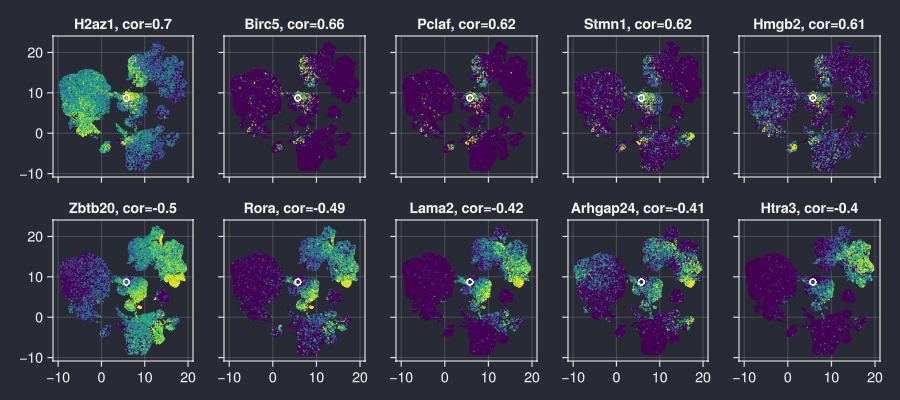

In [24]:
fig, topdf = let ms=2, thr=0.01, cmap=:viridis, topn=5, t=targetcell, val="cor_$targetval"
    pot = ddh.u[neis]
    div = ddh.div[neis]
    rot = ddh.rot[neis]
    # correlations in selected cells
    cor_div = vec(cor(adata.X[neis,:],div))
    cor_rot = vec(cor(adata.X[neis,:],rot))
    df = DataFrame(gene=adata.var_names,cor_div=cor_div,cor_rot=cor_rot)
    df = df[isfinite.(df.cor_div+df.cor_rot),:]
    r = sortperm(df[!,val],rev=true)
    display(permutedims(df[r[1:20],:],1))
    display(permutedims(df[reverse(r[end-20:end]),:],1))
    topdf = df[r[[1:topn; reverse(end-topn+1:end)]],:]
    genes = topdf.gene
    corrs = round.(topdf[!,val],digits=2)
    fig = Figure(size=(900,400))
    axs = [Axis(fig[divrem(i-1,topn).+1...],title="$(genes[i]), cor=$(corrs[i])",aspect=1) for i in 1:2topn]
    idx = indexin(genes,adata.var_names)
    for i in axes(axs,1)
        expr = collect(adata.X[:,idx[i]])
        plt = scatter!(axs[i],pts,color=clip(expr,thr),markersize=ms,colormap=cmap,rasterize=2)
        scatter!(axs[i],pts[t],markersize=5,color=:transparent,strokewidth=2,strokecolor=:white)
        #Colorbar(fig[i+1],plt,vertical=false,flipaxis=false)
        q, r = divrem(i-1,topn)
        q < 1 && (axs[i].xticklabelsvisible=false)
        r > 0 && (axs[i].yticklabelsvisible=false)
    end
    linkaxes!(axs...)
    fig, topdf
end
fig

## Hodge components in Schur subspace

ppal = Dict{String, ColorTypes.RGBA{Float32}}("Day 7" => RGBA(0.8392, 0.1529, 0.1569, 1.0), "Day 5" => RGBA(0.1725, 0.6275, 0.1725, 1.0), "Day 0" => RGBA(0.1216, 0.4667, 0.7059, 1.0), "Day 2" => RGBA(1.0, 0.498, 0.0549, 1.0))


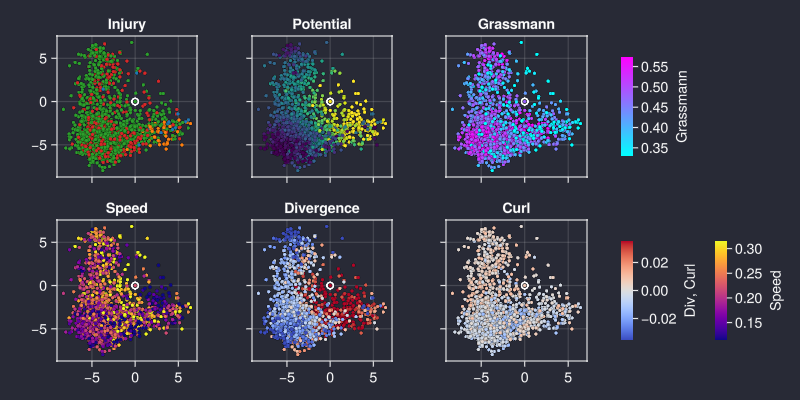

In [25]:
let i=targetcell, suse=tdims, ms=5, clp=0.05, colorby=:injury
    pot = ddh.u[neis]
    div = ddh.div[neis]
    rot = ddh.rot[neis]
    speeds = norm.(eachcol(V[:,neis]))
    vmax = clipmax([div;rot],p=clp)
    lvs = levels(adata.obs[!,colorby])
    ppal = Dict(zip(lvs,resample_cmap(:tab10,max(10,length(lvs)))))
    @show ppal
    fig = Figure(size=(800,400))
    titles = [titlecase(string(colorby)), "Potential", "Grassmann", "Speed", "Divergence", "Curl"]
    axs = [Axis(fig[divrem(i-1,3).+1...],title=titles[i],aspect=1) for i in 1:length(titles)]
    #scatter!(axs[1], xoi, markersize=ms, color=[cpal[c] for c in cats[nei]])
    pars = (markersize=ms,rasterize=2,transparency=false,strokewidth=0.2)
    #@show keys(ppal)
    scatter!(axs[1],xoi,color=[ppal[c] for c in adata.obs[!,colorby][neis]];pars...)
    clipscatter!(ax,vals;args...) = scatter!(ax, xoi, color=clip(vals,clp);pars...,args...)
    pltu = clipscatter!(axs[2], pot, colormap=:viridis)
    pltg = clipscatter!(axs[3], ddh.vgrass[neis]; colormap=:cool)
    plts = clipscatter!(axs[4], speeds, colormap=:plasma)
    pltd = clipscatter!(axs[5], div, colormap=:coolwarm, colorrange=(-vmax,vmax))
    clipscatter!(axs[6], rot; colormap=:coolwarm, colorrange=(-vmax,vmax))
    for i in axes(axs,1)
        # point of interest
        scatter!(axs[i],xoi[1],markersize=ms+1,color=:transparent,strokewidth=2,strokecolor=:white)
    end
    Colorbar(fig[1,4],pltg,label="Grassmann",height=Relative(0.7))
    #Colorbar(fig[1,5],pltu,height=Relative(0.7),label="Potential")
    Colorbar(fig[2,4],pltd,height=Relative(0.7),label="Div, Curl")
    Colorbar(fig[2,5],plts,height=Relative(0.7),label="Speed",vertical=true)
    #Legend(fig[1,5],[melm(ppal[p]) for p in lvs],lvs,labelsize=13)
    [axs[i].xticklabelsvisible = false for i in 1:3]
    [axs[i].yticklabelsvisible = false for i in [2,3,5,6]]
    linkaxes!(axs...)
    fig
end

## Disect the dimension

### Top weights of genes in the Schur vectors

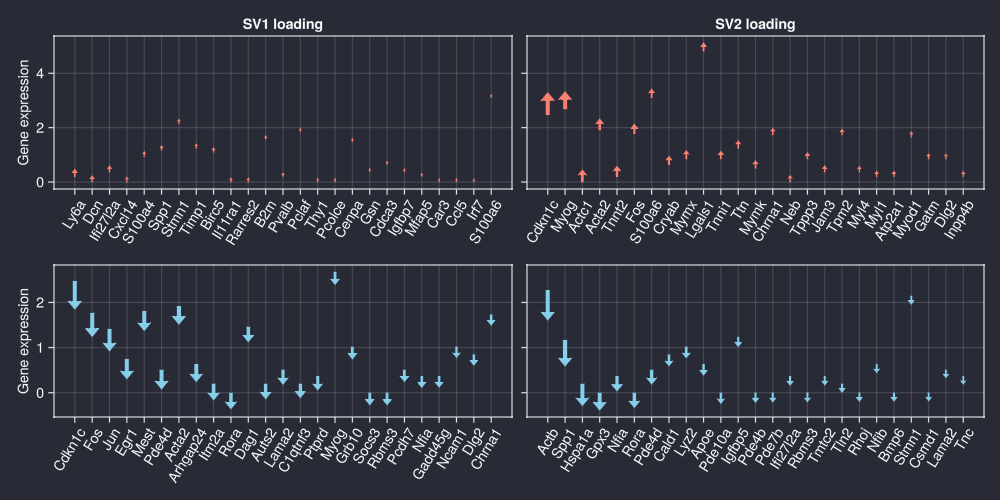

In [26]:
fig, wdf = let i=targetcell, topn=25, suse=tdims
    base = adata.X[i,:]
    W = loadings*S
    #W = S # if no PCA
    ranking = [sortperm(x,rev=true) for x in eachcol(W)]
    fig = Figure(size=(1000,500))
    axs = [Axis(fig[j,i],xticklabelrotation=45.0,) for i in 1:2 for j in 1:2]
    α = 3.0
    for j in 1:2
        for (i,c) in enumerate([:salmon,:skyblue])
            r = i==1 ? ranking[j] : reverse(ranking[j])
            locs = Point2f.(1:topn,base[r[1:topn]])
            arrs = α*Point2f.(fill(0,topn),W[r[1:topn],j])
            arrows2d!(axs[i+2*(j-1)],locs,arrs,color=c,shaftwidth=4)
            axs[i+2*(j-1)].xticks=(1:topn,adata.var_names[r[1:topn]])
        end
    end
    axs[1].title = "SV$(suse[1]) loading" #"s(t) + $α ∂s/∂X"
    axs[3].title = "SV$(suse[2]) loading" #"s(t) + $α ∂s/∂Y"
    colgap!(fig.layout,10)
    [axs[i].ylabel="Gene expression" for i in 1:2]
    [axs[i].yticklabelsvisible=false for i in 3:4]
    linkaxes!(axs[[1,3]]...)
    linkaxes!(axs[[2,4]]...)
    df = DataFrame(
        "names" => adata.var_names,
        "SV$(suse[1])" => W[:,1],
        "SV$(suse[2])" => W[:,2]
    )
    fig, df
end
fig

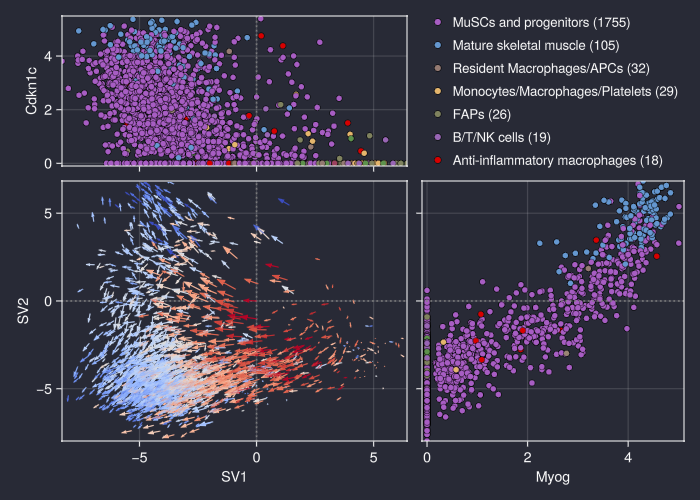

In [27]:
let i=targetcell, genex="Cdkn1c", geney="Myog", ms=8, clp=0.01, cmap=:coolwarm #S
    #genex, geney = topdf.gene[[begin,end]] # top correlated genes
    exprx, expry = eachcol(adata.X[neis,indexin([genex,geney],adata.var_names)])
    # distance to the plane S
    #acol = sqrt.(vec(mapslices(norm,X[:,neis].-X[:,i],dims=1)).^2 - norm.(xoi).^2)
    #acol = [norm(X[:,neis[i]] - X[:,targetcell] - S*x) for (i,x) in enumerate(xoi)]
    #acol = (:white,0.6) #expr
    #acol = norm.(eachcol(V[:,neis]))
    acol = getfield(ddh,targetval)[neis]
    #acol = collect(exprx)
    #acol = maxlyap.(ddh.J[neis]).^-1
    #@show extrema(acol)
    cmax = clipmax(acol,p=clp)
    crange=(-cmax,cmax)
    #crange=(0,cmax)
    #@show crange
    pcol = [get(cpal,c,:lightgrey) for c in cats[neis]]
    lvfreq = sort(freqtable(cats[neis]),rev=true)
    lvs = names(lvfreq[1:min(7,length(lvfreq))])[1] # show top 10 freq.
    lvs = lvs[lvfreq[lvs] .>= 2] # at least 2 cells
    labels = [string(lv)*" ($(lvfreq[lv]))" for lv in lvs]
    W = loadings*S
    scpars = (;markersize=ms, rasterize=2, strokewidth=0.5, color=pcol)
    #fig = Figure(size=(480,360))
    fig = Figure(size=(700,500))
    #fig = Figure(size=(900,600))
    ax0 = Axis(fig[2,1],xlabel="SV$(tdims[1])",ylabel="SV$(tdims[2])")
    ax1 = Axis(fig[1,1],ylabel=genex,height=150)
    ax2 = Axis(fig[2,2],xlabel=geney,)#width=150)
    vlines!(ax0,[0],linestyle=:dot,color=:grey)
    hlines!(ax0,[0],linestyle=:dot,color=:grey)
    β = 1.0*maximum(norm.(voi))^-1
    #arrows2d!(ax0,xoi,β*voi,color=hsvmap(clip(exprx,clp),clip(expry,clp)),tipwidth=6,shaftwidth=0.2,transparency=false,rasterize=2)
    #arrows2d!(ax0,xoi,β*voi,color=:white,tipwidth=5,shaftwidth=0.2,transparency=false,rasterize=2)
    arrows2d!(ax0,xoi,β*voi,color=acol,colormap=cmap,colorrange=crange,tipwidth=6,shaftwidth=0.2,transparency=true,rasterize=2)
    #arr = arrows!(ax0,xoi,β*voi,color=acol,arrowsize=4,colormap=cmap,linewidth=0.8,colorrange=crange,rasterize=2)
    sc = scatter!(ax1,first.(xoi),exprx;scpars...)
    vlines!(ax1,[0],linestyle=:dot,color=:grey)
    xlims!(ax1,extrema(first.(xoi))...)
    ylims!(ax1,extrema(exprx).+[-0.1,0.1]...)
    scatter!(ax2,expry,last.(xoi);scpars...)
    hlines!(ax2,[0],linestyle=:dot,color=:grey)
    xlims!(ax2,extrema(expry).+[-0.1,0.1]...)
    ylims!(ax2,extrema(last.(xoi))...)
    linkxaxes!(ax0,ax1)
    linkyaxes!(ax0,ax2)
    ax1.xticklabelsvisible=false
    ax2.yticklabelsvisible=false
    #Colorbar(fig[2,3],arr,vertical=true,flipaxis=true)
    #Colorbar(fig[3,1],colormap=:hsv,vertical=false,flipaxis=false)
    leg = Legend(fig[1,2],[melm(cpal[p]) for p in lvs],labels,nbanks=1,labelsize=13,)
    #leg.tellwidth = true
    #leg.tellheight = true
    colgap!(fig.layout, 10)
    rowgap!(fig.layout, 10)
    fig
end

## Compare to DEGs

In [28]:
function rankGenesDF(ad, group)
    keys = ["names","logfoldchanges","scores","pvals","pvals_adj"]
    DataFrame([k => [x[group] for x in vec(ad.uns["rank_genes_groups"][k])] for k in keys])
end

rgdf = rankGenesDF(adata,Symbol(targetcluster))
rgdf = [DataFrame(rank=1:size(rgdf,1)) sort(rgdf,:scores,rev=true)]

Row,rank,names,logfoldchanges,scores,pvals,pvals_adj
,Int64,String,Float32,Float32,Float64,Float64
1,1,Ppp1r14b,3.58509,74.9448,0.0,0.0
2,2,Des,4.59137,74.6737,0.0,0.0
3,3,Dag1,4.06141,74.5903,0.0,0.0
4,4,Pde4d,4.18736,74.5182,0.0,0.0
5,5,Hsp90ab1,1.80936,72.618,0.0,0.0
6,6,Rplp0,1.58196,71.9573,0.0,0.0
7,7,Rpl4,1.52747,71.5243,0.0,0.0
8,8,Eef1a1,1.46827,71.4517,0.0,0.0
9,9,Cdh15,7.44676,71.34,0.0,0.0


highlight = 5×8 DataFrame
 Row │ names   SV1        SV2          rank   logfoldchanges  scores      pvals        pvals_adj
     │ String  Float64    Float64      Int64  Float32         Float32     Float64      Float64
─────┼─────────────────────────────────────────────────────────────────────────────────────────────
   1 │ Mest    -0.143495  -0.00302219     29        4.97362    65.0015    0.0          0.0
   2 │ Cdkn1c  -0.207287   0.270264      191        2.65252    39.5567    0.0          0.0
   3 │ Egr1    -0.145672   0.02487       893        0.826617   20.0743    1.23706e-89  1.53253e-88
   4 │ Jun     -0.160485   0.0400554    7728       -0.02247     0.907058  0.364376     0.494027
   5 │ Fos     -0.174902   0.117845    14383       -0.421326  -10.6705    1.39816e-26  6.37823e-26
highlight = 5×8 DataFrame
 Row │ names   SV1         SV2        rank   logfoldchanges  scores     pvals        pvals_adj
     │ String  Float64     Float64    Int64  Float32         Float32    Float64      

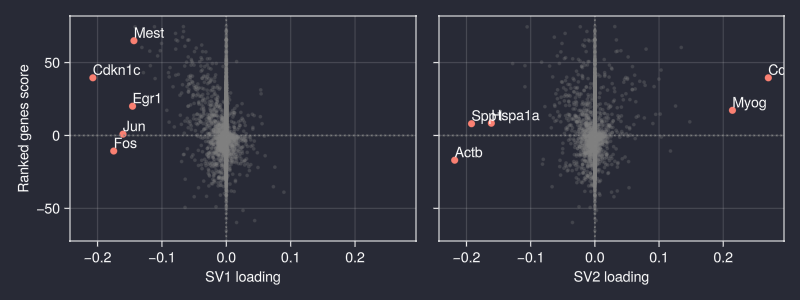

In [29]:
mdf = innerjoin(wdf,rgdf,on=:names)
let topn = 5
    fig = Figure(size=(800,300))
    axs = [Axis(fig[1,i],xlabel="SV$(tdims[i]) loading") for i in 1:2]
    axs[1].ylabel="Ranked genes score"
    for (i,toshow) in enumerate(["SV$k" for k in tdims])
        vals = mdf[!,toshow]
        scatter!(axs[i],vals,mdf.scores,markersize=5,color=(:grey,0.3),rasterize=2)
        highlight = mdf[invperm(sortperm(abs.(vals),rev=true)) .<= topn,:]
        @show highlight
        scatter!(axs[i],highlight[!,toshow],highlight.scores,markersize=10,color=:salmon,rasterize=2)
        for j in 1:size(highlight,1)
            text!(
                axs[i], Point2f(highlight[j,toshow],highlight.scores[j]),
                text = highlight.names[j], fontsize=14, #color=:white,
                align=(:left,:bottom)
            )
        end
    end
    axs[2].yticklabelsvisible=false
    hlines!.(axs,[0],linestyle=:dot,color=:grey)
    vlines!.(axs,[0],linestyle=:dot,color=:grey)
    linkxaxes!(axs...)
    linkyaxes!(axs...)
    fig
end

In [30]:
#sort(rgdf[rgdf.pvals_adj .< 0.1,:],:pvals)
@show sum(rgdf.pvals_adj .< 0.01)
sort(rgdf,:scores,rev=true)

sum(rgdf.pvals_adj .< 0.01) = 8550


Row,rank,names,logfoldchanges,scores,pvals,pvals_adj
,Int64,String,Float32,Float32,Float64,Float64
1,1,Ppp1r14b,3.58509,74.9448,0.0,0.0
2,2,Des,4.59137,74.6737,0.0,0.0
3,3,Dag1,4.06141,74.5903,0.0,0.0
4,4,Pde4d,4.18736,74.5182,0.0,0.0
5,5,Hsp90ab1,1.80936,72.618,0.0,0.0
6,6,Rplp0,1.58196,71.9573,0.0,0.0
7,7,Rpl4,1.52747,71.5243,0.0,0.0
8,8,Eef1a1,1.46827,71.4517,0.0,0.0
9,9,Cdh15,7.44676,71.34,0.0,0.0


In [31]:
rgdf[[gn ∈ ["Myog","Cdkn1c"] for gn in rgdf.names],:]

Row,rank,names,logfoldchanges,scores,pvals,pvals_adj
,Int64,String,Float32,Float32,Float64,Float64
1,191,Cdkn1c,2.65252,39.5567,0.0,0.0
2,1193,Myog,3.82559,17.2496,1.12747e-66,1.03856e-65
